## 헬스케어 보험료 데이터

### 1. 데이터 이해 및 준비

데이터셋의 각 컬럼이 의미하는 바를 설명하세요. 특히, charges 컬럼은 어떤 값을 가지며, 이 값이 무엇을 나타내는지 설명하세요..

각 데이터에 대해서 확인해보고 싶은 정보(가설)를 미리 구상해보세요.

### 2. 기본 통계량 및 데이터 구조

데이터셋의 기본 통계량을 확인하세요. 각 수치형 변수의 평균, 중앙값, 표준편차는 어떻게 되는지 확인해보세요.

데이터셋의 각 변수의 데이터 타입을 확인하고, 범주형 변수와 수치형 변수를 구분해보세요.

### 3. 범주형 데이터 분석

sex 변수의 각 범주에 속하는 데이터의 개수를 시각화 해보세요.

region 변수의 범주별 charges의 분포를 시각화하고, 지역이 보험료에 미치는 영향을 분석하세요.

### 4. 수치형 데이터 분석

age 변수의 분포를 시각화하고, 나이에 따른 charges의 분포를 분석하세요. 특정 나이대에서 보험료가 높은 경향이 있는지 확인하세요.

BMI변수의 분포를 시각화하고, bmi가 charges에 미치는 영향을 분석하세요.

### 5. 상관관계 분석

수치형 변수들 간의 상관관계 히트맵을 생성하고, charges과 가장 상관관계가 높은 변수는 무엇인지 확인하세요.

### 6. 데이터 시각화

smoker 여부와 sex에 따른 charges의 분포를 시각화하고, 흡연 여부와 성별이 보험료에 미치는 영향을 분석하세요.

### 7. 결론 도출

데이터 분석을 통해 얻은 주요 인사이트를 요약하세요. 어떤 변수들이 charges에 가장 큰 영향을 미치는지 설명하세요.

분석 결과를 바탕으로, 보험료를 예측하기 위한 간단한 모델을 제안해보세요. 이 모델에서 어떤 변수를 사용할 것인지 설명하세요.



--------------------------------

(1) 데이터 이해 및 준비 : 각 칼럼미 의미하는 바

- age : 만 나이
- sex : 성별
- bmi : 체질량지수
- children : 자녀(부양가족) 수
- smoker : 흡연 여부
- region : 거주지역
- charges : 개인별 의료보험 비용

(2) 기본 통계량 및 데이터 구조

In [1]:
import pandas as pd
import numpy as np

(2)-1. 기본통계량

In [2]:
# 데이터 불러오기
df = pd.read_csv('insurance.csv')

# 데이터 크기(행, 열 세이프) 확인
print(df.shape)
print("\n" + "="*50 + "\n")

# 상위 5개 데이터 확인
display(df.head())
print("\n" + "="*50 + "\n")

# 데이터 정보 (변수명, 데이터 타입, 결측치 수)
print(df.info())

(1338, 7)




,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520




<class 'pandas.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   str    
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   str    
 5   region    1338 non-null   str    
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), str(3)
memory usage: 94.5 KB
None


(2)-2. 각 변수의 데이터 타입 및 대푯값

- age: 수치형(연속)
- sex: 범주형(명목)
- bmi: 수치형(연속)
- children: 수치형(연속)
- smoker: 범주형(명목)
- region: 범주형(명목)
- charges: 수치형(연속)

In [4]:
display(df.describe())
print("\n" + "="*50 + "\n")

numeric_modes = df[['age', 'bmi', 'children', 'charges']].mode().iloc[0]   # 최빈값
print(numeric_modes)

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010




age           18.0000
bmi           32.3000
children       0.0000
charges     1639.5631
Name: 0, dtype: float64


In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

In [9]:
from matplotlib import font_manager

for _f in ['Malgun Gothic', 'AppleGothic', 'NanumGothic',
           'Noto Sans CJK KR', 'Noto Sans CJK JP']:
    if _f in {f.name for f in font_manager.fontManager.ttflist}:
        plt.rcParams['font.family'] = _f
        break
plt.rcParams['axes.unicode_minus'] = False   # 음수 부호 깨짐 방지
print('font:', plt.rcParams['font.family'])

font: ['Malgun Gothic']


(2)-3. 수치형 데이터 특징
 * 나이 분포에서는 20세 미만이 높게 나타나나, 평균과 중앙값이 비슷하게 나타나 20~60대에 비교적 고르게 분포되어있음을 알 수 있음
 * BMI 분포는 정규분포에 가까운 형태를 띔. 평균인 30부근에 많이 몰려있음
 * 자녀 수는 0(없음)이 압도적으로 높고, 계단식으로 감소함을 보여줌
 * 개인별 의료보험료에서만 평균값과 중앙값이 크게 차이 발생. 양의 왜도(오른쪽으로 꼬리가 긴) 형태의 분포를 보여줌

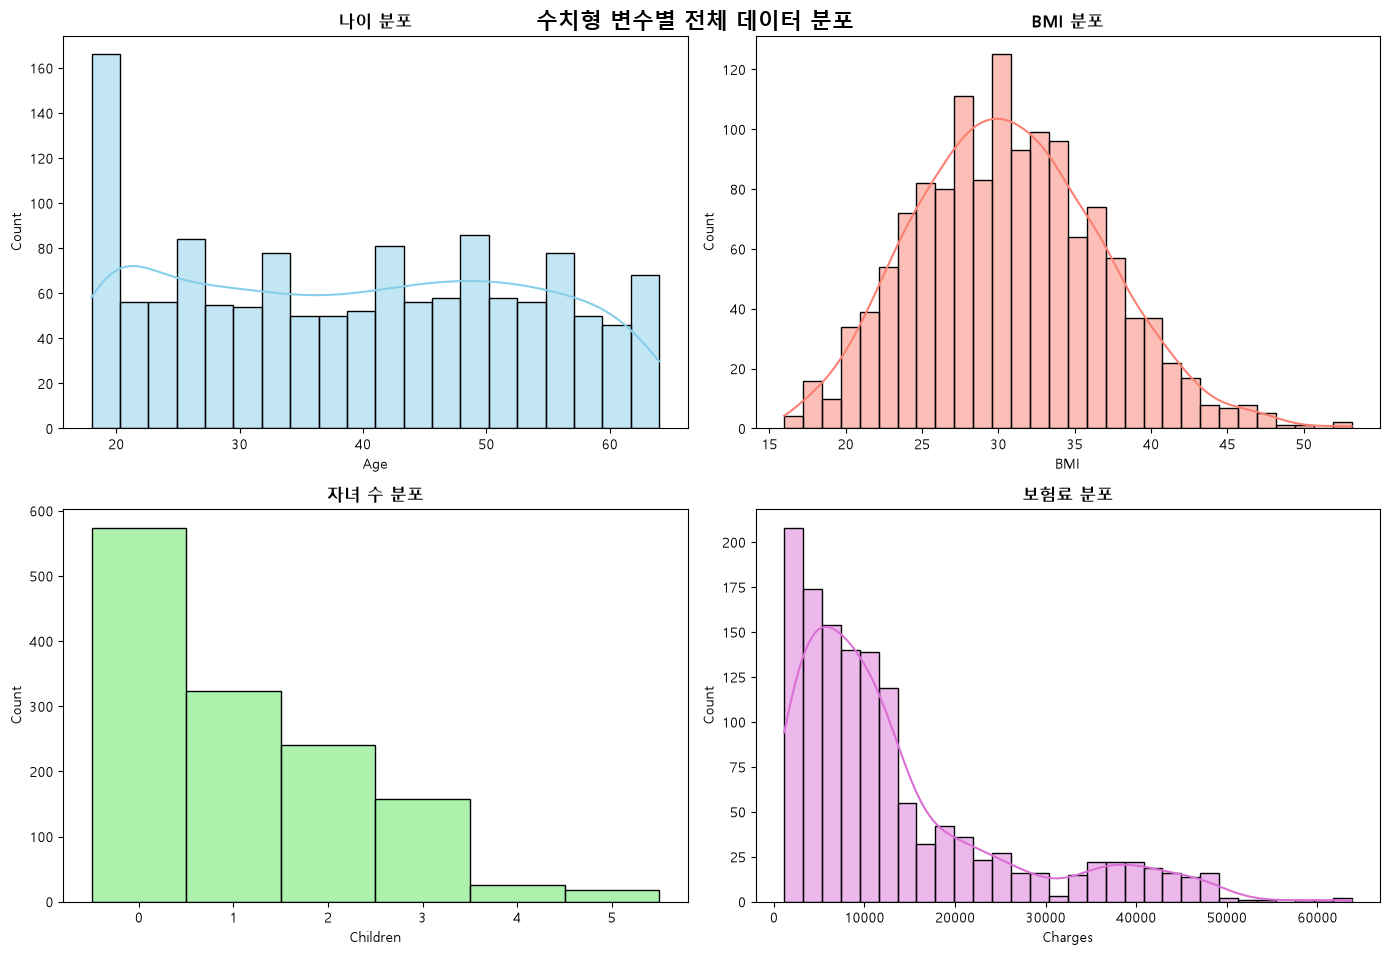

In [ ]:
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(14, 10))

fig.suptitle('수치형 변수별 전체 데이터 분포', fontsize=16, fontweight='bold', y=0.95)

# 나이(age) 분포
sns.histplot(df['age'], kde=True, ax=axes[0, 0], color='skyblue', bins=20)
axes[0, 0].set_title('나이 분포', fontsize=12, fontweight='bold')
axes[0, 0].set_xlabel('Age')
axes[0, 0].set_ylabel('Count')

# 체질량지수(bmi) 분포
sns.histplot(df['bmi'], kde=True, ax=axes[0, 1], color='salmon', bins=30)
axes[0, 1].set_title('BMI 분포', fontsize=12, fontweight='bold')
axes[0, 1].set_xlabel('BMI')
axes[0, 1].set_ylabel('Count')

# 자녀 수(children) 분포
sns.histplot(df['children'], kde=False, ax=axes[1, 0], color='lightgreen', discrete=True)
axes[1, 0].set_title('자녀 수 분포', fontsize=12, fontweight='bold')
axes[1, 0].set_xlabel('Children')
axes[1, 0].set_ylabel('Count')

# 의료비 보험료(charges) 분포
sns.histplot(df['charges'], kde=True, ax=axes[1, 2 if False else 1], color='orchid', bins=30)
axes[1, 1].set_title('보험료 분포', fontsize=12, fontweight='bold')
axes[1, 1].set_xlabel('Charges')
axes[1, 1].set_ylabel('Count')


plt.tight_layout()
plt.show()

(3) 범주형 데이터 분석

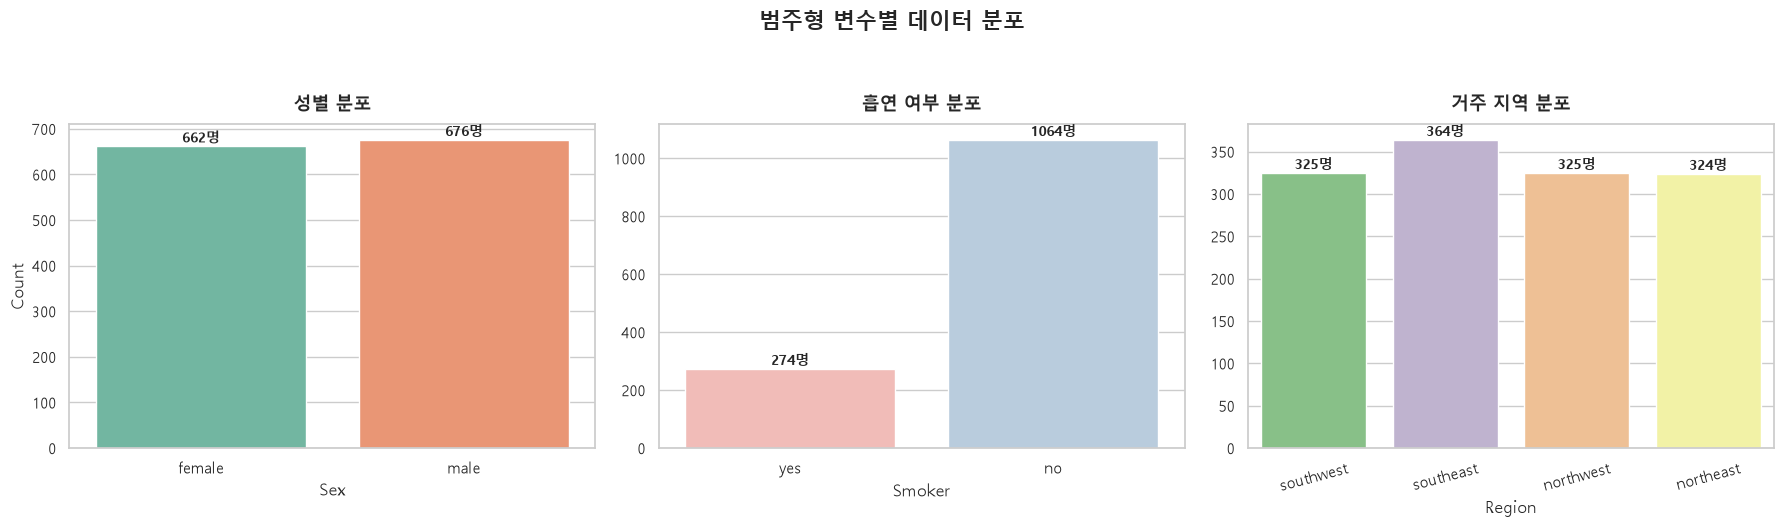

In [13]:
fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(18, 5))

fig.suptitle('범주형 변수별 데이터 분포', fontsize=16, fontweight='bold', y=1.05)
sns.set_theme(style="whitegrid", font="Malgun Gothic")

# 성별(sex) 분포
sns.countplot(x='sex', hue='sex', data=df, ax=axes[0], palette='Set2', legend=False)
axes[0].set_title('성별 분포', fontsize=13, fontweight='bold', pad=10)
axes[0].set_xlabel('Sex')
axes[0].set_ylabel('Count')

for p in axes[0].patches:
    axes[0].annotate(f'{int(p.get_height())}명', (p.get_x() + p.get_width() / 2., p.get_height()),
                     ha='center', va='center', xytext=(0, 6), textcoords='offset points', fontsize=10, fontweight='bold')


# 흡연 여부(smoker) 분포
sns.countplot(x='smoker', hue='smoker', data=df, ax=axes[1], palette='Pastel1', legend=False)
axes[1].set_title('흡연 여부 분포', fontsize=13, fontweight='bold', pad=10)
axes[1].set_xlabel('Smoker')
axes[1].set_ylabel('')

for p in axes[1].patches:
    axes[1].annotate(f'{int(p.get_height())}명', (p.get_x() + p.get_width() / 2., p.get_height()),
                     ha='center', va='center', xytext=(0, 6), textcoords='offset points', fontsize=10, fontweight='bold')


# 거주 지역(region) 분포
sns.countplot(x='region', hue='region', data=df, ax=axes[2], palette='Accent', legend=False)
axes[2].set_title('거주 지역 분포', fontsize=13, fontweight='bold', pad=10)
axes[2].set_xlabel('Region')
axes[2].set_ylabel('') 
axes[2].tick_params(axis='x', rotation=15)

for p in axes[2].patches:
    axes[2].annotate(f'{int(p.get_height())}명', (p.get_x() + p.get_width() / 2., p.get_height()),
                     ha='center', va='center', xytext=(0, 6), textcoords='offset points', fontsize=10, fontweight='bold')


# 레이아웃 정렬 및 출력
plt.tight_layout()
plt.show()

(3)-1. 범주형 데이터 확인 결과

* sex (성별): 남성과 여성의 샘플 수가 거의 1:1에 가깝게 균등하게 분포
* smoker (흡연 여부): 비흡연자(No)의 비율이 흡연자(Yes)에 비해 압도적으로 많음. 보험료와 연관성 있을 수 있음
* region (지역): 4개 지역의 데이터 수가 매우 일정하고 고르게 분포

(4) 수치형 데이터 분석

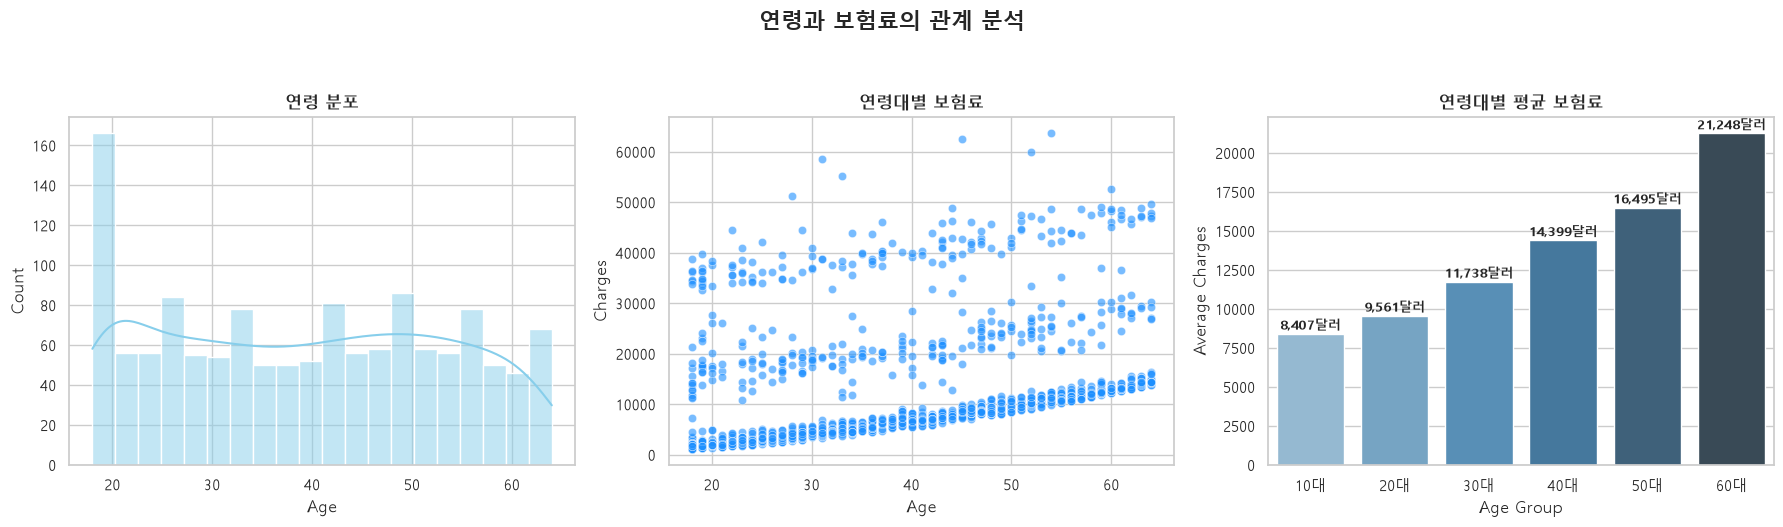

In [18]:
df['age_group'] = (df['age'] // 10) * 10
df['age_group_name'] = df['age_group'].astype(str) + '대'

# 그래프 레이아웃 설정 (1행 3열)
fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(18, 5))
fig.suptitle('연령과 보험료의 관계 분석', fontsize=16, fontweight='bold', y=1.05)

# age 변수의 분포
sns.histplot(df['age'], kde=True, ax=axes[0], color='skyblue', bins=20)
axes[0].set_title('연령 분포', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Age')

# 나이에 따른 charges의 분포
sns.scatterplot(x='age', y='charges', data=df, ax=axes[1], alpha=0.6, color='dodgerblue')
axes[1].set_title('연령대별 보험료', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Age')
axes[1].set_ylabel('Charges')

# 특정 나이대별 평균 보험료 비교
age_charge_mean = df.groupby('age_group_name')['charges'].mean().reset_index()
age_order = ['10대', '20대', '30대', '40대', '50대', '60대']
sns.barplot(x='age_group_name', y='charges', data=age_charge_mean, order=age_order, ax=axes[2], palette='Blues_d', hue='age_group_name', legend=False)
axes[2].set_title('연령대별 평균 보험료', fontsize=12, fontweight='bold')
axes[2].set_xlabel('Age Group')
axes[2].set_ylabel('Average Charges')

for p in axes[2].patches:
    axes[2].annotate(f'{int(p.get_height()):,}달러', (p.get_x() + p.get_width() / 2., p.get_height()),
                     ha='center', va='center', xytext=(0, 6), textcoords='offset points', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()

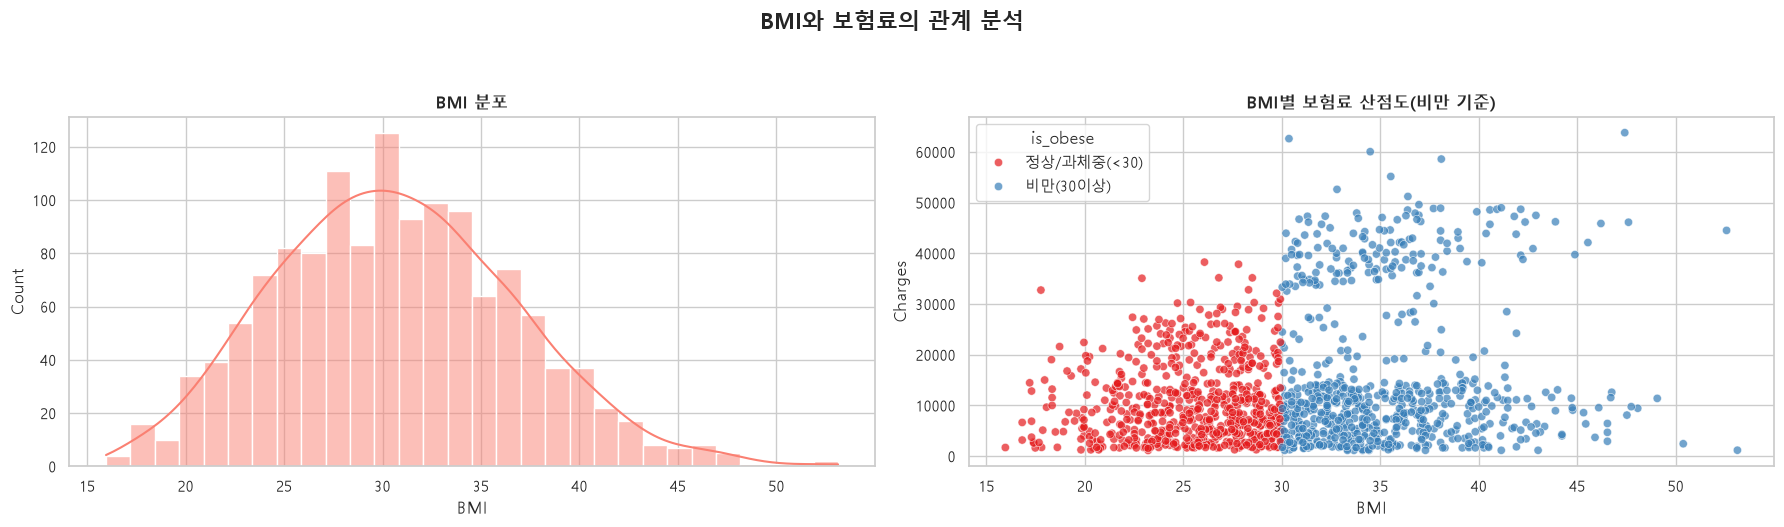

In [21]:
df['is_obese'] = df['bmi'].apply(lambda x: '비만(30이상)' if x >= 30 else '정상/과체중(<30)')

fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(18, 5))
fig.suptitle('BMI와 보험료의 관계 분석', fontsize=16, fontweight='bold', y=1.05)

# BMI 변수의 분포
sns.histplot(df['bmi'], kde=True, ax=axes[0], color='salmon', bins=30)
axes[0].set_title('BMI 분포', fontsize=12, fontweight='bold')
axes[0].set_xlabel('BMI')

# BMI와 보험료의 산점도
sns.scatterplot(x='bmi', y='charges', hue='is_obese', data=df, ax=axes[1], alpha=0.7, palette='Set1')
axes[1].set_title('BMI별 보험료 산점도(비만 기준)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('BMI')
axes[1].set_ylabel('Charges')

plt.tight_layout()
plt.show()

(4)-1. 수치형 데이터 확인 결과

 * 연령대별 보험료 및 연령대별 평균 보험료를 보면, 전반적으로 연령대가 올라감에 따라 보험료가 증가하는 양의 상관관계 패턴이 보임
 * 하지만, 연령대별 분포를 보면 같은 나이대에도 크게 3곳으로 분류되어있어, 나이 외 다른 변수 확인이 필요해보임
 * BMI의 경우, 정규분포에 가까운 분포를 가지고 있음
 * BMI와 보험료는 상관관계가 거의 없는 것으로 보이나, 특정 구간(비만 구간)의 일부 데이터들이 BMI 비만 기준을 넘긴 후 폭등하는 현상이 보임. 다른 요인 추가 파악 필요

(5) 상관관계 분석

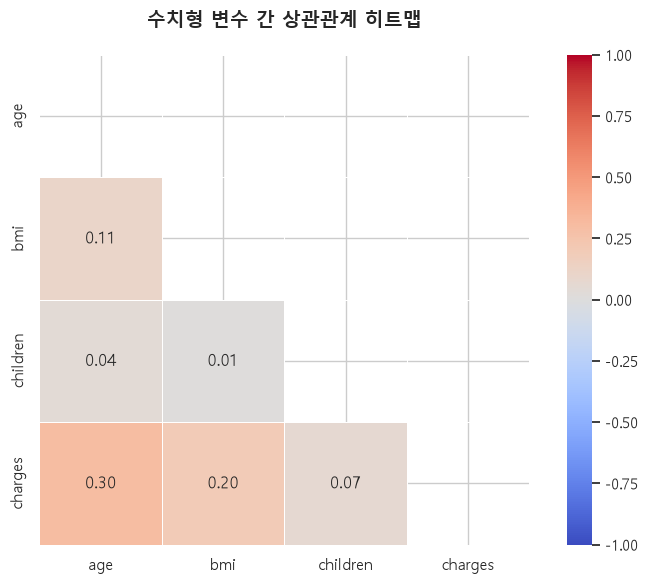

=== charges(보험료)와의 상관계수 순위 ===
age         0.299008
bmi         0.198341
children    0.067998
Name: charges, dtype: float64


In [24]:
numeric_df = df[['age', 'bmi', 'children', 'charges']]
corr_matrix = numeric_df.corr()
masks = np.triu(np.ones_like(corr_matrix, dtype=bool), 1)
masks = masks | np.eye(len(masks), dtype=bool)

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, vmin=-1, vmax=1, annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.5, square=True, mask=masks)
plt.title('수치형 변수 간 상관관계 히트맵', fontsize=14, fontweight='bold', pad=20)

plt.tight_layout()
plt.show()


print("=== charges(보험료)와의 상관계수 순위 ===")
print(corr_matrix['charges'].sort_values(ascending=False).drop(['charges']))

(5)-1. 상관관계 분석 결과

 * 나이(age)가 가장 상관관계가 높음(0.299). 약한 양의 상관관계를 보임. 이는 대체로 연령대가 높을수록 보험료가 높아진다는 의미
 * 두번째는 BMI가 약한 상관관계를 보임(0.198). 하지만 나이와 BMI모두 그렇게 높지 않은 상관관계여서, 실제 보험료와 관계되는 변수는 나이, BMI, 자녀수가 아닐것으로 추정됨
 * 흡연여부 등 추가 범주형 변수를 포함한 상관관계 분석이 필요함

(6) 데이터 시각화

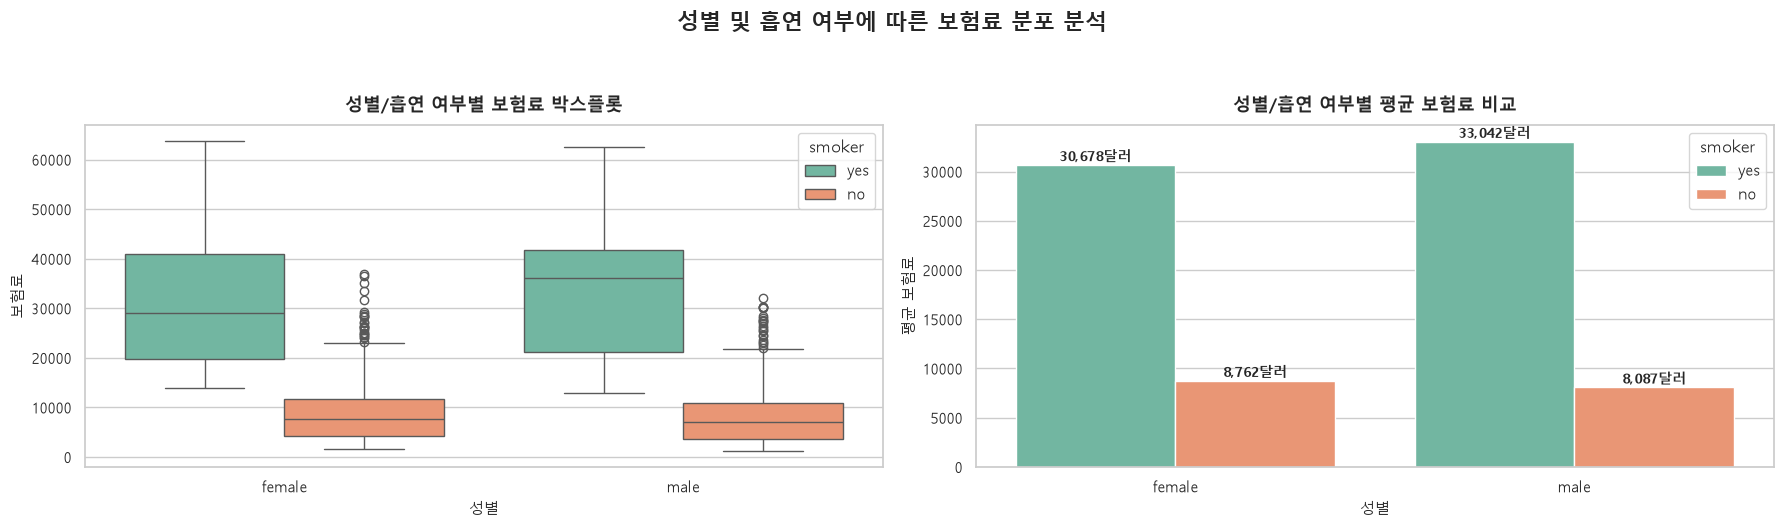

=== 성별 및 흡연 여부별 보험료 기술통계 ===


count      mean    median
sex    smoker                           
female no        547   8762.30   7639.42
       yes       115  30679.00  28950.47
male   no        517   8087.20   6985.51
       yes       159  33042.01  36085.22

In [25]:
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(18, 5))
fig.suptitle('성별 및 흡연 여부에 따른 보험료 분포 분석', fontsize=16, fontweight='bold', y=1.05)

# Box Plot (전체적인 분포와 이상치 확인)
sns.boxplot(x='sex', y='charges', hue='smoker', data=df, ax=axes[0], palette='Set2')
axes[0].set_title('성별/흡연 여부별 보험료 박스플롯', fontsize=13, fontweight='bold', pad=10)
axes[0].set_xlabel('성별', fontsize=11)
axes[0].set_ylabel('보험료', fontsize=11)

# Bar Plot (그룹별 평균 보험료 비교)
sns.barplot(x='sex', y='charges', hue='smoker', data=df, ax=axes[1], palette='Set2', errorbar=None)
axes[1].set_title('성별/흡연 여부별 평균 보험료 비교', fontsize=13, fontweight='bold', pad=10)
axes[1].set_xlabel('성별', fontsize=11)
axes[1].set_ylabel('평균 보험료', fontsize=11)

for p in axes[1].patches:
    height = p.get_height()
    if height > 0:
        axes[1].annotate(f'{int(height):,}달러', 
                         (p.get_x() + p.get_width() / 2., height),
                         ha='center', va='center', 
                         xytext=(0, 6), textcoords='offset points', 
                         fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

# 그룹별 평균 및 중앙값
print("=== 성별 및 흡연 여부별 보험료 기술통계 ===")
summary = df.groupby(['sex', 'smoker'])['charges'].agg(['count', 'mean', 'median']).round(2)
display(summary)


(6)-1. 데이터 시각화 분석 결과

 * 각 성별에서 흡연여부에 따른 보험료 차이가 명확히 드러남 (성별에 관계없이, 흡연자의 보험료 최하 구간이 비흡연자의 75%구간보다 위쪽에 형성되어있고, 흡연자의 중앙 50%구간 및 최대치가 압도적으로 위쪽에 형성되어 있음)
 * 보험료에 관해 직접적인 영향을 끼치는 건 나이, BMI, 자녀수 등이 아닌 흡연여부임을 알 수 있음
 * 추가적으로 t-검정 진행 결과 t=32.7, p-value는 매우 작은 값(귀무가설 기각)으로, 실제로 흡연여부로 인해 유의미한 차이가 있음을 확인

In [30]:
from scipy import stats

df['smoker'] = df['smoker'].astype(str).str.strip()

is_smoker = df['smoker'].str.lower() == 'yes'
is_non_smoker = df['smoker'].str.lower() == 'no'

smoker_charges = df[is_smoker]['charges'].dropna()
non_smoker_charges = df[is_non_smoker]['charges'].dropna()

print(f"흡연자 데이터 수: {len(smoker_charges)}명")
print(f"비흡연자 데이터 수: {len(non_smoker_charges)}명")
print("\n" + "="*40 + "\n")

if len(smoker_charges) > 1 and len(non_smoker_charges) > 1:
    t_stat, p_val = stats.ttest_ind(smoker_charges, non_smoker_charges, equal_var=False)
    
    print("=== 흡연 여부에 따른 보험료 t-test 결과 ===")
    print(f"t-통계량 : {t_stat:.4f}")
    print(f"p-value : {p_val}")


흡연자 데이터 수: 274명
비흡연자 데이터 수: 1064명


=== 흡연 여부에 따른 보험료 t-test 결과 ===
t-통계량 : 32.7519
p-value : 5.889464446716999e-103
